## Parte 6 — Reflexão Final e Abordagem Híbrida

### Cenários de uso

A regressão logística é mais indicada em cenários onde existem dados rotulados disponíveis, pois consegue aprender padrões específicos de fraude com maior precisão.

Já o Isolation Forest é mais adequado em situações onde não há rótulos ou quando se deseja identificar comportamentos anômalos de forma geral, especialmente para detectar novos padrões de fraude ainda desconhecidos.

### Combinação de métodos

Sim, é possível combinar os dois métodos em um sistema híbrido. Nesse tipo de abordagem, um modelo supervisionado (como a regressão logística) pode ser utilizado para classificação principal, enquanto um modelo não supervisionado (como o Isolation Forest) pode atuar como uma camada adicional de detecção de anomalias.

Essa combinação pode aumentar a segurança do sistema, permitindo identificar tanto fraudes conhecidas quanto comportamentos suspeitos ainda não mapeados.

### Aplicação em outros domínios

O problema de detecção de fraude está diretamente relacionado à detecção de anomalias em outros domínios, como segurança da informação, monitoramento de sistemas, detecção de falhas industriais e análise de comportamento de usuários.

Em todos esses casos, o objetivo é identificar padrões fora do comportamento esperado, muitas vezes sem a disponibilidade de rótulos, o que torna técnicas como o Isolation Forest amplamente aplicáveis.

### Experimento adicional — Modelo híbrido

Como extensão da análise, foi realizado um experimento combinando a Regressão Logística e o Isolation Forest, com o objetivo de avaliar se a utilização conjunta dos modelos poderia melhorar a detecção de fraudes.

A estratégia adotada foi classificar uma transação como fraude apenas quando ambos os modelos a identificassem como suspeita.

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv('../data/creditcard.csv')

X = df.drop('Class', axis=1)
y = df['Class']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [5]:
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
model_if = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

model_if.fit(X_train)

y_pred_if = model_if.predict(X_test)
y_pred_if = np.where(y_pred_if == -1, 1, 0)

In [17]:
y_pred_hybrid = np.where(
    (y_pred_lr == 1) & (y_pred_if == 1),
    1,
    0
)

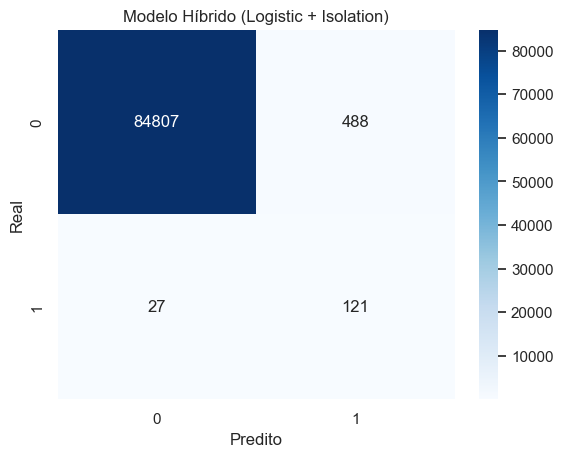

In [18]:
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)

sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues')
plt.title('Modelo Híbrido (Logistic + Isolation)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

### Análise do modelo híbrido

O modelo híbrido, utilizando a combinação entre regressão logística e Isolation Forest com contamination = 0.05, apresentou um desempenho equilibrado na detecção de fraudes.

Observou-se uma redução significativa nos falsos negativos, totalizando 27 casos, o que indica que a maior parte das fraudes foi corretamente identificada. Esse resultado é especialmente relevante, considerando que falsos negativos representam transações fraudulentas que não seriam detectadas pelo sistema.

Por outro lado, o modelo apresentou 488 falsos positivos, indicando que algumas transações legítimas foram classificadas como fraude. Apesar disso, esse nível de erro pode ser considerado aceitável dependendo do contexto, principalmente em cenários onde a prioridade é minimizar perdas financeiras.

A combinação dos modelos permitiu aproveitar os pontos fortes de cada abordagem: a regressão logística contribui com a identificação de padrões aprendidos a partir dos dados rotulados, enquanto o Isolation Forest auxilia na detecção de comportamentos anômalos.

De forma geral, o modelo híbrido se mostrou uma alternativa interessante, apresentando melhor capacidade de detecção de fraudes em comparação ao uso isolado do Isolation Forest, além de oferecer uma abordagem complementar à regressão logística.

### Conexão com detecção de anomalias em outros domínios

O problema de detecção de fraude está diretamente relacionado à detecção de anomalias em diversos outros domínios, pois em todos esses cenários o objetivo é identificar comportamentos que fogem do padrão esperado.

Em segurança da informação, por exemplo, técnicas semelhantes são utilizadas para detectar acessos suspeitos, invasões ou atividades incomuns em sistemas. No monitoramento de sistemas, anomalias podem indicar falhas, quedas de serviço ou comportamentos inesperados em aplicações.

Na indústria, a detecção de anomalias é aplicada para identificar falhas em máquinas e equipamentos antes que causem problemas maiores, permitindo manutenção preventiva. Já em análise de comportamento de usuários, pode ser utilizada para identificar ações incomuns que indiquem risco ou fraude.

Em todos esses casos, assim como na detecção de fraudes, existe o desafio de lidar com eventos raros e muitas vezes pouco representados nos dados, além da dificuldade de identificar padrões que nem sempre são claramente distintos.

Dessa forma, as técnicas utilizadas neste projeto, como modelos supervisionados e não supervisionados, podem ser aplicadas em diferentes contextos, demonstrando a importância da detecção de anomalias como uma área ampla e relevante dentro da ciência de dados.